# Stage 2: Statistics Project — Gene Expression Cancer RNA-Seq
**Dataset**: Gene Expression Cancer RNA-Seq (TCGA) via UCI ML Repo
**Goal**: Apply descriptive stats, distribution analysis, hypothesis testing, and confidence intervals to explore differential gene expression across cancer types.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

# ── Loading data ──────────────────────────────────────────────
genes_df = pd.read_csv('/Users/meschacolongo/gene-expression-analysis/data/data.csv')
labels_df = pd.read_csv('/Users/meschacolongo/gene-expression-analysis/data/labels.csv')

gene_df = genes_df.rename(columns={'Unnamed: 0': 'Sample_id'})
label_df = labels_df.rename(columns={'Unnamed: 0': 'Sample_id'})

df = pd.merge(gene_df, label_df, on='Sample_id', how='left')
df = df.set_index('Sample_id')

# ── Data overview ─────────────────────────────────────────────
print(f"Shape: {df.shape}")
print(f"\nCancer types: {df['Class'].unique()}")
print(f"\nSamples per type:\n{df['Class'].value_counts()}")
df[['gene_1', 'gene_2', 'gene_3', 'Class']].head()

Shape: (801, 20532)

Cancer types: <StringArray>
['PRAD', 'LUAD', 'BRCA', 'KIRC', 'COAD']
Length: 5, dtype: str

Samples per type:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


,gene_1,gene_2,gene_3,Class
Sample_id,,,,
sample_0,2.017209,3.265527,5.478487,PRAD
sample_1,0.592732,1.588421,7.586157,LUAD
sample_2,3.511759,4.327199,6.881787,PRAD
sample_3,3.663618,4.507649,6.659068,PRAD
sample_4,2.655741,2.821547,6.539454,BRCA


## Section 1 — Descriptive Statistics

Before running any statistical tests, we summarise the central tendency and spread of gene_1, gene_2, and gene_3 across all five cancer types. The coefficient of variation (CV) is particularly useful here — it expresses variability relative to the mean, allowing fair comparison across genes with different expression scales.

In [3]:
# ── Descriptive statistics per cancer type ─────────────────

genes = ['gene_1', 'gene_2', 'gene_3']

rows = []
for cancer in df['Class'].unique():
    subset = df[df['Class'] == cancer]
    for gene in genes:
        vals = subset[gene]
        rows.append({
            'Cancer Type': cancer,
            'Gene': gene,
            'Mean': vals.mean(),
            'Median': vals.median(),
            'Std': vals.std(),
            'CV (%)': (vals.std() / vals.mean()) * 100
        })

desc_df = pd.DataFrame(rows).round(4)
desc_df = desc_df.sort_values(['Gene', 'Cancer Type']).reset_index(drop=True)
desc_df

,Cancer Type,Gene,Mean,Median,Std,CV (%)
0,BRCA,gene_1,2.8397,2.9796,1.1703,41.2112
1,COAD,gene_1,3.4384,3.5256,0.9398,27.3317
2,KIRC,gene_1,2.3981,2.4462,1.1250,46.9122
3,LUAD,gene_1,3.3583,3.5532,1.2321,36.6886
4,PRAD,gene_1,3.4410,3.5551,1.0886,31.6368
5,BRCA,gene_2,2.8058,2.8186,0.9574,34.1227
6,COAD,gene_2,3.2386,3.3035,0.8179,25.2553
7,KIRC,gene_2,2.4480,2.4159,0.8101,33.0911
8,LUAD,gene_2,3.4577,3.5362,1.0727,31.0234
9,PRAD,gene_2,3.9713,3.9400,0.9261,23.3195


### Interpretation

Several patterns emerge from the descriptive statistics:

- **gene_1** shows the highest variability across all cancer types, with CV values ranging from 27% (COAD) to 47% (KIRC). This wide spread suggests gene_1 expression is sensitive to cancer subtype — making it a strong candidate for further statistical testing.
- **KIRC consistently shows the lowest mean expression** for both gene_1 (2.40) and gene_2 (2.45), hinting at a biologically distinct expression profile compared to the other four cancer types.
- **gene_3** is remarkably stable across all cancer types, with CV values all below 9%. This low variability suggests gene_3 may not be a strong differentiator between cancer subtypes.
- **PRAD** shows the highest mean gene_2 expression (3.97) with relatively low CV (23%), indicating consistently elevated expression across its samples.

These observations guide our next step: testing whether the differences we see — especially in gene_1 — are statistically significant, or could be due to chance.

## Section 2 — Distribution Analysis

Before choosing a statistical test, we must understand the distribution of our data. Many common tests (like ANOVA) assume normality. If that assumption is violated, we need non-parametric alternatives.

Here we examine the distributions of gene_1 and gene_3 visually using histograms with KDE curves, then formally test for normality using the Shapiro-Wilk test. We focus on these two genes because gene_1 showed the highest variability and gene_3 the lowest — making them interesting contrasts.

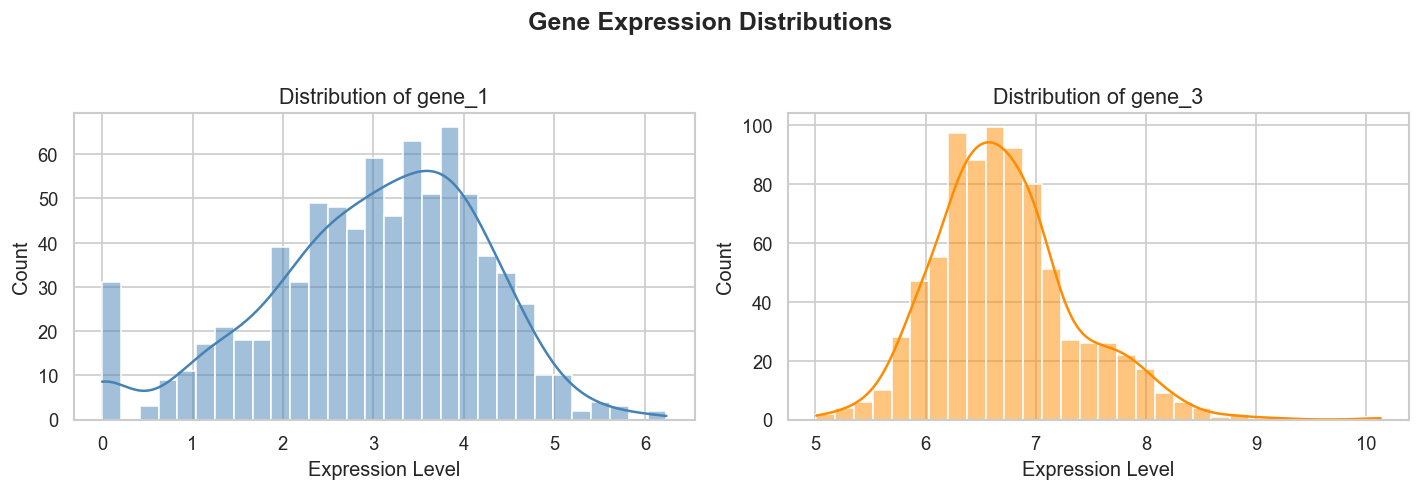

Shapiro-Wilk Normality Test Results
gene_1: W=0.9758, p=2.9805e-10 → Non-normal
gene_3: W=0.9729, p=4.8409e-11 → Non-normal


In [4]:
# ── Histograms with KDE ────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, gene, color in zip(axes, ['gene_1', 'gene_3'], ['steelblue', 'darkorange']):
    sns.histplot(df[gene], kde=True, ax=ax, color=color, bins=30)
    ax.set_title(f'Distribution of {gene}', fontsize=13)
    ax.set_xlabel('Expression Level')
    ax.set_ylabel('Count')

plt.suptitle('Gene Expression Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../stats_images/distributions_gene1_gene3.png', bbox_inches='tight')
plt.show()

# ── Shapiro-Wilk normality test ────────────────────────────

print("Shapiro-Wilk Normality Test Results\n" + "="*40)
for gene in ['gene_1', 'gene_3']:
    stat, p = stats.shapiro(df[gene])
    result = "Non-normal" if p < 0.05 else "Normal"
    print(f"{gene}: W={stat:.4f}, p={p:.4e} → {result}")

### Interpretation

**Visually:**
- **gene_1** shows a broad, roughly bell-shaped distribution but with a slight left skew and an irregular tail — already hinting at non-normality.
- **gene_3** appears more symmetric but has a sharper peak than a true normal distribution would produce (leptokurtic), with a long right tail.

**Shapiro-Wilk Test:**
- **gene_1**: W=0.9758, p=2.98e-10 → **Non-normal**
- **gene_3**: W=0.9729, p=4.84e-11 → **Non-normal**

Both p-values are far below our significance threshold of α=0.05, so we reject the null hypothesis of normality for both genes.

**Why this matters:** Since our data violates the normality assumption, we cannot use parametric tests like ANOVA. Instead, we will use the **Kruskal-Wallis test** — a non-parametric alternative that compares group distributions without assuming normality.

## Section 3 — Hypothesis Testing

We now formally test whether gene_1 expression differs significantly across the five cancer types.

**Hypotheses:**
- **H₀:** The distribution of gene_1 expression is the same across all cancer types
- **H₁:** At least one cancer type has a significantly different gene_1 expression distribution

We use the **Kruskal-Wallis test** (non-parametric equivalent of one-way ANOVA) since we confirmed non-normality in Section 2. If the overall test is significant, we follow up with **Dunn's post-hoc test** with Bonferroni correction to identify exactly which pairs differ.

Kruskal-Wallis Test — gene_1
H-statistic: 89.8876
p-value:     1.3912e-18
Result:      Reject H₀ — significant differences exist

Dunn's Post-hoc Test — Bonferroni-corrected p-values

        BRCA    COAD    KIRC    LUAD  PRAD
BRCA  1.0000  0.0007  0.0014  0.0001   0.0
COAD  0.0007  1.0000  0.0000  1.0000   1.0
KIRC  0.0014  0.0000  1.0000  0.0000   0.0
LUAD  0.0001  1.0000  0.0000  1.0000   1.0
PRAD  0.0000  1.0000  0.0000  1.0000   1.0


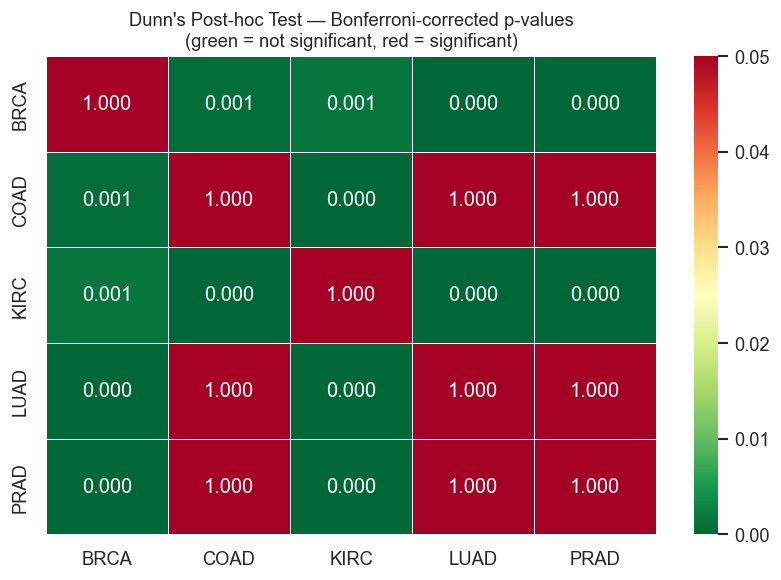

In [5]:
# ── Kruskal-Wallis test ────────────────────────────────────

groups = [group['gene_1'].values for _, group in df.groupby('Class')]

stat, p = stats.kruskal(*groups)
print("Kruskal-Wallis Test — gene_1")
print("="*40)
print(f"H-statistic: {stat:.4f}")
print(f"p-value:     {p:.4e}")
print(f"Result:      {'Reject H₀ — significant differences exist' if p < 0.05 else 'Fail to reject H₀'}")

# ── Dunn's post-hoc test ───────────────────────────────────

dunn = sp.posthoc_dunn(df, val_col='gene_1', group_col='Class', p_adjust='bonferroni')

print("\nDunn's Post-hoc Test — Bonferroni-corrected p-values\n")
print(dunn.round(4))

# ── Heatmap of p-values ────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    dunn, annot=True, fmt='.3f', cmap='RdYlGn_r',
    linewidths=0.5, ax=ax, vmin=0, vmax=0.05
)
ax.set_title("Dunn's Post-hoc Test — Bonferroni-corrected p-values\n(green = not significant, red = significant)", fontsize=11)
plt.tight_layout()
plt.savefig('../stats_images/dunn_posthoc_heatmap.png', bbox_inches='tight')
plt.show()

### Interpretation

**Kruskal-Wallis Test:**
- H-statistic: 89.89, p=1.39e-18 → We reject H₀ with overwhelming confidence.
- Gene_1 expression is **not the same across all cancer types** — at least one group differs significantly.

**Dunn's Post-hoc Test (Bonferroni-corrected):**

The heatmap reveals a striking pattern — **KIRC is the outlier:**
- KIRC vs BRCA: p=0.0014 ✓ significant
- KIRC vs COAD: p=0.0000 ✓ significant
- KIRC vs LUAD: p=0.0000 ✓ significant
- KIRC vs PRAD: p=0.0000 ✓ significant

KIRC differs significantly from **every other cancer type**. Meanwhile, COAD, LUAD, and PRAD show no significant differences among themselves (all p=1.000), suggesting they share a similar gene_1 expression profile.

**Biological note:** KIRC (Kidney Renal Clear Cell Carcinoma) consistently showing lower gene_1 expression than all other cancer types may reflect a tissue-specific regulatory mechanism or a metabolic reprogramming characteristic of renal cell carcinoma. This would be a meaningful hypothesis to investigate further with domain-specific literature.

## Section 4 — Confidence Intervals

The Kruskal-Wallis and Dunn's tests confirmed that KIRC differs significantly from all other cancer types in gene_1 expression. Here we visualise 95% confidence intervals per cancer type to show the magnitude and separation of these differences graphically.

A 95% CI means: if we repeated this sampling many times, 95% of the constructed intervals would contain the true population mean. **Non-overlapping intervals between groups provide strong visual evidence of significant differences.**

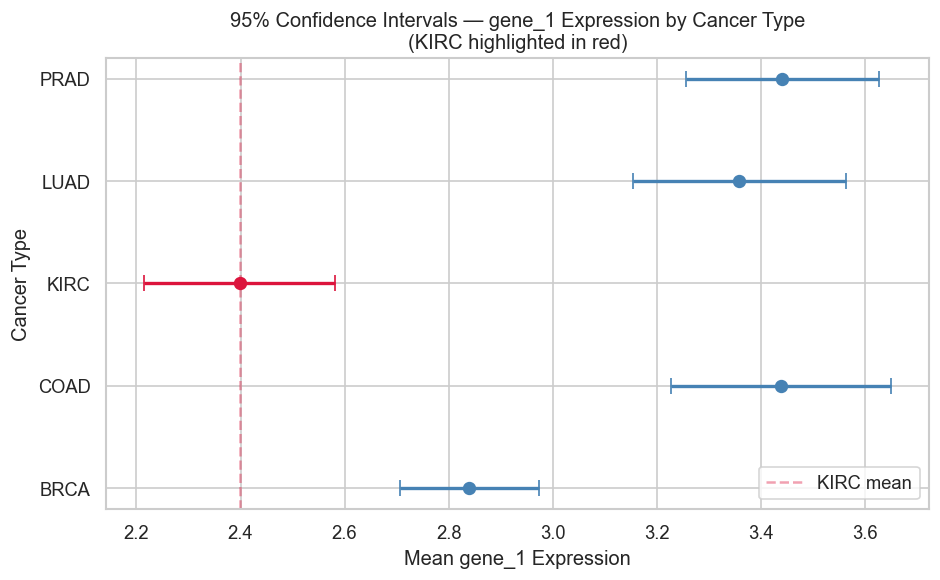

In [6]:
# ── 95% Confidence intervals per cancer type ───────────────

cancer_types = df['Class'].unique()
means, lower, upper, labels_ci = [], [], [], []

for cancer in sorted(cancer_types):
    subset = df[df['Class'] == cancer]['gene_1']
    n = len(subset)
    mean = subset.mean()
    se = stats.sem(subset)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    
    means.append(mean)
    lower.append(mean - ci[0])
    upper.append(ci[1] - mean)
    labels_ci.append(cancer)

# ── Errorbar plot ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

for i, (cancer, mean, lo, hi) in enumerate(zip(labels_ci, means, lower, upper)):
    color = 'crimson' if cancer == 'KIRC' else 'steelblue'
    ax.errorbar(
        x=mean, y=cancer,
        xerr=[[lo], [hi]],
        fmt='o', color=color,
        ecolor=color, elinewidth=2,
        capsize=5, markersize=7
    )

ax.set_xlabel('Mean gene_1 Expression', fontsize=12)
ax.set_ylabel('Cancer Type', fontsize=12)
ax.set_title('95% Confidence Intervals — gene_1 Expression by Cancer Type\n(KIRC highlighted in red)', fontsize=12)
ax.axvline(x=means[labels_ci.index('KIRC')], color='crimson', linestyle='--', alpha=0.4, label='KIRC mean')
ax.legend()

plt.tight_layout()
plt.savefig('../stats_images/confidence_intervals_gene1.png', bbox_inches='tight')
plt.show()

### Interpretation

The confidence interval plot makes the statistical findings visually undeniable:

- **KIRC's entire CI (≈2.2 – 2.6) sits completely to the left** of every other cancer type's interval, with no overlap whatsoever.
- **BRCA** is the next lowest (≈2.7 – 3.0), already well separated from KIRC.
- **COAD, LUAD, and PRAD** cluster tightly between 3.2 and 3.6, consistent with the Dunn's test showing no significant differences among them.

The dashed red line marking the KIRC mean (≈2.40) emphasises just how far below the other groups KIRC sits — roughly 1 full expression unit lower than COAD, LUAD, and PRAD.

This visual evidence, combined with the Kruskal-Wallis result (p=1.39e-18) and Dunn's post-hoc confirmation, makes a compelling case that **KIRC has a distinctly suppressed gene_1 expression profile** relative to all other cancer types in this dataset.

## Section 5 — Biological Interpretation & Conclusion

### Summary of Findings

This analysis applied a full statistical workflow to explore differential gene expression across five cancer types (BRCA, KIRC, LUAD, PRAD, COAD) using the TCGA RNA-Seq dataset. The table below summarises the key results:

| Analysis | Result |
|---|---|
| Descriptive Stats | KIRC has the lowest mean gene_1 and gene_2 expression; gene_3 is stable across all types |
| Normality (Shapiro-Wilk) | Both gene_1 and gene_3 are non-normal (p < 0.05) |
| Kruskal-Wallis | Significant differences in gene_1 across cancer types (H=89.89, p=1.39e-18) |
| Dunn's Post-hoc | KIRC differs significantly from all four other cancer types (all p < 0.05) |
| Confidence Intervals | KIRC CI has zero overlap with all other groups |

### Biological Interpretation

The consistent suppression of gene_1 expression in KIRC (Kidney Renal Clear Cell Carcinoma) across every statistical method applied is unlikely to be a random finding. Several biological mechanisms could explain this pattern:

- **Epigenetic silencing:** Promoter hypermethylation is a well-documented mechanism in renal cell carcinoma that can suppress gene expression at scale.
- **Metabolic reprogramming:** KIRC is characterised by a shift toward aerobic glycolysis (the Warburg effect), which fundamentally alters transcriptional programs compared to other solid tumours.
- **Tissue-of-origin effects:** Kidney tissue has a distinct transcriptional baseline compared to breast, lung, prostate, and colon tissue — meaning some expression differences may reflect normal tissue biology rather than tumour-specific changes.

### Limitations

- This analysis focused on only three genes (gene_1, gene_2, gene_3) out of 20,531 available features. The findings cannot be generalised to the full transcriptome.
- Gene identifiers are anonymised in this dataset, which prevents direct biological annotation or literature lookup.
- Statistical significance does not imply clinical relevance — effect sizes and replication in independent cohorts would be needed before drawing biomedical conclusions.

### Next Steps

This statistical foundation naturally leads into Stage 3 of the roadmap:
- **Machine learning:** Can gene expression profiles reliably classify cancer type? Which genes are the most discriminative features?
- **Feature selection:** Apply variance filtering or statistical testing across all 20,531 genes to identify the strongest candidates — not just gene_1, gene_2, gene_3.
- **Dimensionality reduction:** PCA or UMAP to visualise whether cancer types form separable clusters in high-dimensional expression space.